#how to biuld agent inlangchain
##what is tools
##how to create tools
##tools callling

##two specialiy of llm
* reasoning(understand the question and break down the question llm can thing)
* language genration
## thing llm can not do
* call api
* cannot intereact with database
##tool
* noting but funtion
tool is just a phython function that can call the llm can call when need and give input to llm
##tools(2 type)
* built in tool

tool which lan chaing provide to u u dont have to write manual code u just call it and use it  simply import it and use it
# popular built in tools
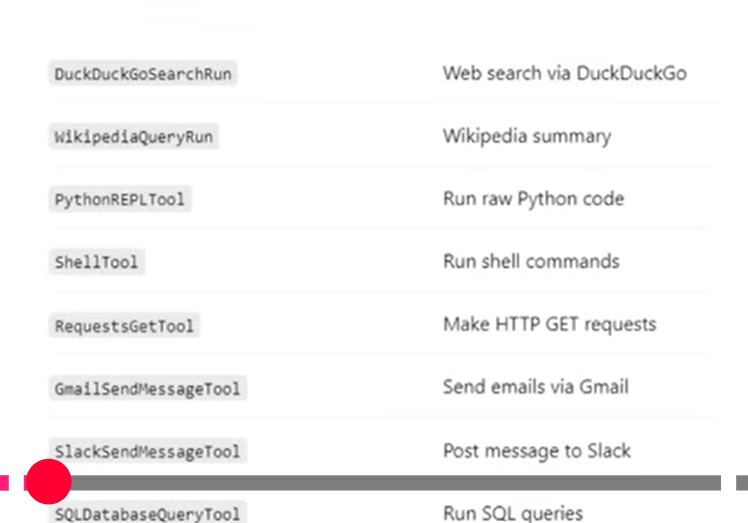
* custom tools

any tool which is need for only our company u can make that tool


LLM Alone
=
Can only think and generate text

LLM + Tools
=
Can search internet
Can run Python
Can query database
Can send emails
Can call APIs

In [1]:
!pip install langchain langchain-core langchain-community pydantic duckduckgo-search langchain_experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [5]:
!pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 6.2 MB/s eta 0:00:00


In [6]:
from ddgs import DDGS

In [10]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()
 #will make object name serch_tool of class DuckDuckGoSearchRun
#these tools are also runnables

results = search_tool.invoke('what is fertility rate of india ')
#because theses function are runnable too we can invoke thses function

print(results)
'''
Your Code
    ↓
DDGS package
    ↓
DuckDuckGo Search
    ↓
Gets Results
    ↓
Returns Text

'''

April 16, 2026 - The total fertility rate of India in 2017 stood at 2.2. Due to the large population, poverty and strain on resources, the Indian government initiated population control efforts to decrease birth rate with the current target being at 2.1 children per woman. December 2, 2025 - The Total Fertility Rate - a key demographic indicator that estimates the average number of children that a woman will have in her lifetime - has dropped to 1.9 children per woman on average in India as of 2023.[1] When a country's Total Fertility ... 3 days ago - Yes, absolutelyNo, let nature take ... placed India’s fertility rate at 1.9 births per woman, below the replacement level of 2.1.While India remains the world's most populous nation with more than 1.46 billion people, the latest data suggests ... 3 days ago - The agency estimated India's fertility rate at 1.9 births per woman, again placing it below the replacement benchmark. Although India remains the world's most populous country with a

'\nYour Code\n    ↓\nDDGS package\n    ↓\nDuckDuckGo Search\n    ↓\nGets Results\n    ↓\nReturns Text\n\n'

In [11]:
print(search_tool.name)
print(search_tool.description)
print(search_tool.args)

duckduckgo_search
A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
{'query': {'description': 'search query to look up', 'title': 'Query', 'type': 'string'}}


## Built-in Tool - Shell Tool

In [16]:
from langchain_community.tools import ShellTool

shell_tool = ShellTool()
#commend line can excetuce these code
#if u write command line to delete the filw thses file can be delete from colab
r = shell_tool.invoke('pwd')
r1 = shell_tool.invoke('ls')   #in google colab there is only one smaple data
r2=shell_tool.invoke('whoami')  #in colab it is root
print(r)
print(r1)
print(r2)
'''
import subprocess

This module lets Python:

Open programs
Run terminal commands
Capture output

Example without LangChain:
'''

Executing command:
 pwd
Executing command:
 ls
Executing command:
 whoami
/content

sample_data

root



/usr/local/lib/python3.12/dist-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


'\nimport subprocess\n\nThis module lets Python:\n\nOpen programs\nRun terminal commands\nCapture output\n\nExample without LangChain:\n'

## how to build the custom tool from langchain
- when u need to call ur own api key ur own llm
- ur own bussiness logic
- u want ur llm to intereact with your own database


In [17]:
from langchain_core.tools import tool

# Custom tools
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""  # these """ """ this will tell llm what it will going to do
    return a + b

@tool #@ --> help to communicated with llm
#tell llm it is tool
def multiply(a: int, b: int) -> int:
# -> these is importnat beacuse --> tell --> return type

    """Multiply two numbers"""
    return a * b


In [20]:
#how to call the too
#tool is runnable too
# hence it is invoke
answer=multiply.invoke({"a":1,"b":2})
'''
have to pass dictionary here
{
"a":1,
"b":2
}
'''
print(answer)#this is nt normal function it is tool
#these tool will intereact will llm

2


## any tool will have 3 attributes
- name
- description
- args

we don send tool to llm , llm see schema json schema

In [21]:
print(multiply.name) #name of the tool
print(multiply.description) #description of tool
print(multiply.args) #what input does the tool take

multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


##ways to create custom tool(3 way)
- with @tool
- usinf struture tools and pydantic (theses is strick with input u if it is interger input acn be char it have to be int

- using base class

In [22]:
from langchain.tools import BaseTool
from typing import Type

In [24]:
from pydantic import BaseModel, Field

# arg schema using pydantic

class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

/tmp/ipykernel_3058/7304043.py:6: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  a: int = Field(required=True, description="The first number to add")
/tmp/ipykernel_3058/7304043.py:7: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  b: int = Field(required=True, description="The second number to add")


In [25]:
class MultiplyTool(BaseTool):
    name: str = "multiply"
    description: str = "Multiply two numbers"

    args_schema: Type[BaseModel] = MultiplyInput  # we will etll what is class

    def _run(self, a: int, b: int) -> int:
        return a * b

In [28]:
multiply_tool_instance = MultiplyTool()
an = multiply_tool_instance.invoke({"a":1,"b":2})
print(an)

2


In [30]:
a=MultiplyTool()
r=a.invoke({"a":0,"b":2})
print(r)

0


##base model
- it is the astract class in langchain
-all tools should follow base class
- base class will tell how langchain will behave in class
-@tools and SuctureOftool (pyandantic) is already in baseclass

In [31]:
from langchain_core.tools import tool
from typing import Type

In [32]:

  #mutiple tool class will ineritate from Baseclass
  #can define own atrribut and function


class MultiplyTool(BaseTool):
    name: str = "multiply"
    description: str = "Multiply two numbers"

    args_schema: Type[BaseModel] = MultiplyInput

    def _run(self, a: int, b: int) -> int: #the name of the function should be _run always
        return a * b

In [33]:
multiply_tool = MultiplyTool()

In [34]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)

print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'title': 'B', 'type': 'integer'}}


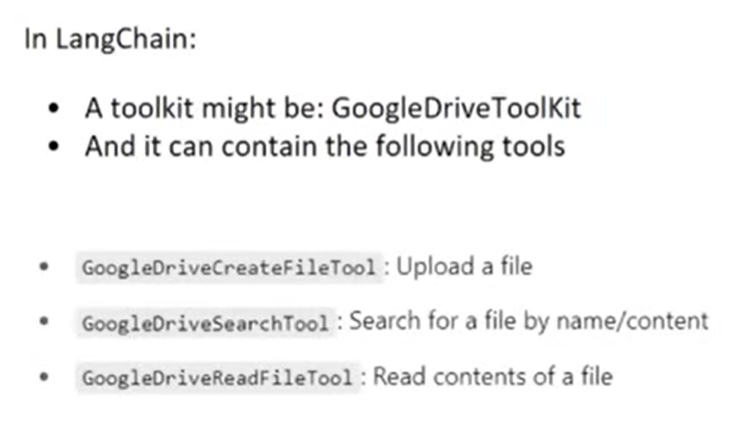

#tooklit
- u u are making mutiple tool related to google drive
- one tool is uploading tooklit in google drive googledrivefileToll
- if all the tool is related to google drive
- u can club all and put it into google drive  tooklit
- u can make custom tool too
-make it reuseable

In [35]:
from langchain_core.tools import tool

# Custom tools
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b

In [36]:
class MathToolkit: #Mathtoolkit --> name of took lit
    def get_tools(self):
        return [add, multiply] # put the name of all which u want in tool kit

In [37]:
toolkit = MathToolkit()  # as mathToolkit is a class first thing u do is to make object
tools = toolkit.get_tools()

for tool in tools:   # for i in toolkit.get_tools()
                         #print(i,i.description)
    print(tool.name, "=>", tool.description)  #this method can be reuseable

add => Add two numbers
multiply => Multiply two numbers
